# Job Market Intelligence Dashboard

An analysis of real tech job postings, built with a Python + SQL data pipeline and AI-powered skill extraction.

**Data source:** Adzuna API (India) — 200 postings across 4 search queries (Data Analyst, Python Developer, Data Scientist, SQL Developer)

**Tools used:** Python, requests, SQLite, Pandas, Seaborn/Matplotlib, Gemini API 

## 1. How the data was collected

The pipeline has four stages:

1. **Collect:** `fetch_jobs.py` calls the Adzuna API and saves raw JSON responses
2. **Store:** `load_data.py` cleans each job and inserts it into a SQLite database, skipping duplicates
3. **Analyze:** Pandas and Seaborn turn SQL data into charts
4. **Enrich:** `ai_extract.py` uses an LLM (Gemini) to extract named tools and technologies from job descriptions

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

conn = sqlite3.connect("jobs.db")
df = pd.read_sql("SELECT * FROM jobs", conn)

print("Rows, columns:", df.shape)
df[["title", "company", "state", "posted_date"]].head()

Rows, columns: (200, 13)


,title,company,state,posted_date
0,Data Analyst,KRFS,Karnataka,2026-09-07
1,Data Analyst,Pharmanovia,Maharashtra,2026-09-02
2,Data Analyst,Nians,NaN,2026-09-01
3,Data Analyst,Indofast Energy,NaN,2026-09-03
4,Data Analyst,Cornerstone OnDemand,Maharashtra,2026-09-09


## 2. Data quality

Real data is messy, so I checked it before analysing it:

- **250 postings fetched, 200 unique.** The "data analyst" search was run twice, so 50 duplicates were skipped using the job ID as a primary key.
- **Salary is missing for 160 of 200 postings** (80%), so salary findings are only a rough signal.
- **State is missing for 42 postings** and company name for 5.
- **Some postings have old creation dates (2019-2021).** The companies look genuine, so this is most likely Adzuna keeping the original listing date on reposted jobs.
- **Descriptions are cut off at 500 characters** by the API, which limits what the AI step can see.

In [2]:
missing = df[["company", "state", "salary_min"]].isna().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
company         5
state          42
salary_min    160
dtype: int64


## 3. Who is hiring, and where?

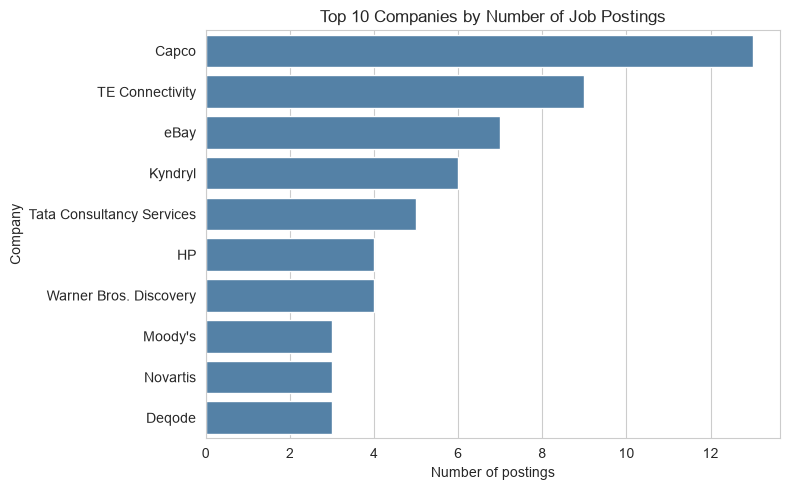

In [3]:
top_companies = df["company"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_companies.values, y=top_companies.index, color="steelblue")
plt.title("Top 10 Companies by Number of Job Postings")
plt.xlabel("Number of postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

**Insight:** Capco posted the most roles (13), followed by TE Connectivity (9) and eBay (7). Hiring is spread across many companies rather than dominated by one, since most appear only once or twice.

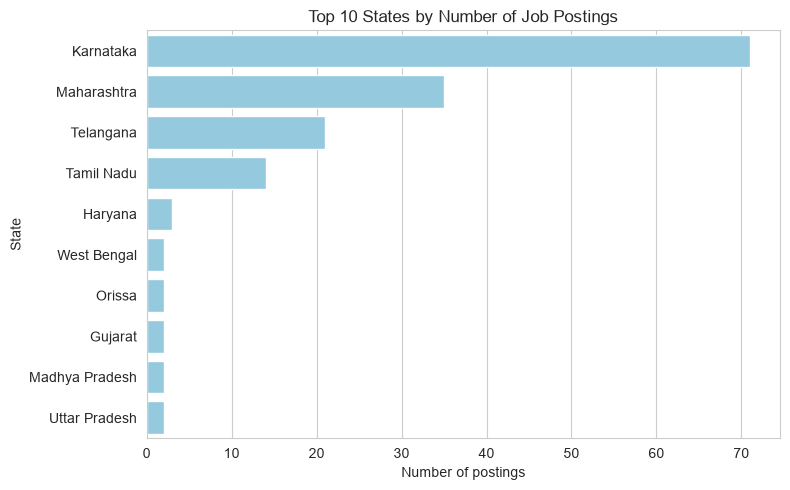

In [4]:
top_states = df["state"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_states.values, y=top_states.index, color="skyblue")
plt.title("Top 10 States by Number of Job Postings")
plt.xlabel("Number of postings")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Insight:** Karnataka leads with 71 postings, about double Maharashtra (35), followed by Telangana (21) and Tamil Nadu (14). This fits Bangalore, Mumbai/Pune, Hyderabad and Chennai being India's main tech hubs. Note that 42 postings had no state recorded, so these counts are a lower bound.

## 4. Salary and timing

                           mean  count
search_query                          
sql developer     638095.238095     21
python developer  531578.947368     19


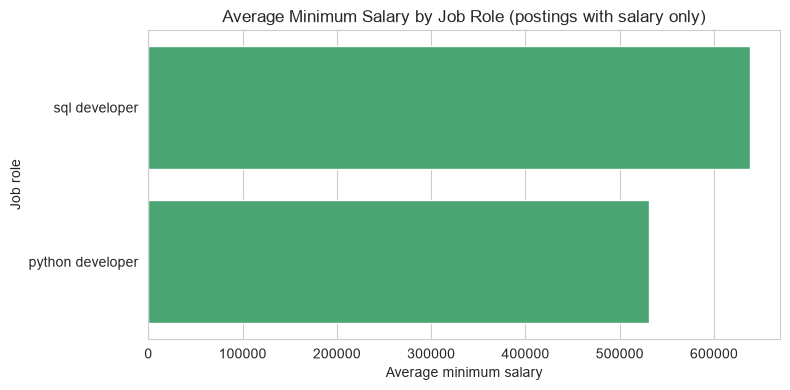

In [5]:
salary_df = df[df["salary_min"].notna()]
avg_salary = salary_df.groupby("search_query")["salary_min"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print(avg_salary)

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_salary["mean"], y=avg_salary.index, color="mediumseagreen")
plt.title("Average Minimum Salary by Job Role (postings with salary only)")
plt.xlabel("Average minimum salary")
plt.ylabel("Job role")
plt.tight_layout()
plt.show()

**Insight:** Among postings that list a salary, SQL developer roles average about 638K and Python developer roles about 531K. **Only 40 of 200 postings (20%) include a salary**, and none of them came from the Data Analyst or Data Scientist searches, so this comparison covers just two roles and should be read as a rough signal, not a market benchmark.

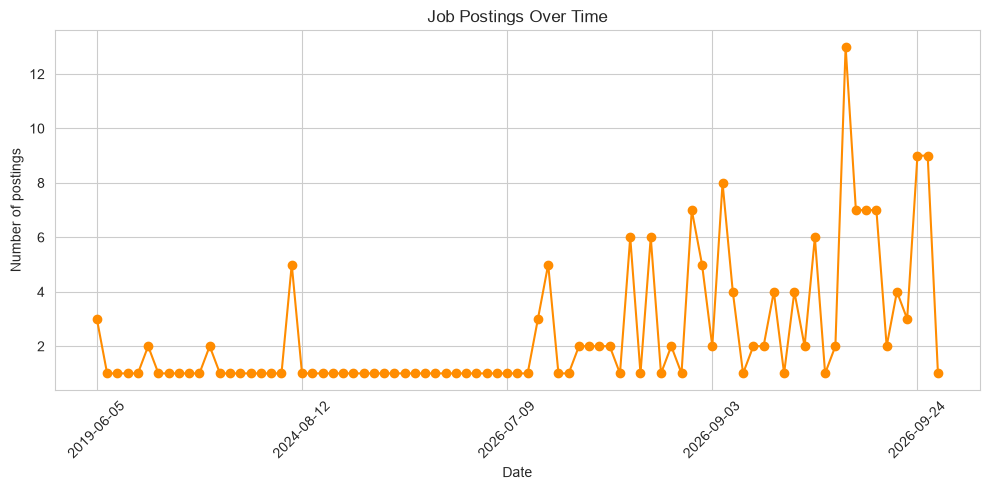

In [6]:
postings_by_date = df.groupby("posted_date").size()

plt.figure(figsize=(10, 5))
postings_by_date.plot(kind="line", marker="o", color="darkorange")
plt.title("Job Postings Over Time")
plt.xlabel("Date")
plt.ylabel("Number of postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Most postings were created in August-September 2026, with a peak of 13 on a single day (2026-09-17). A handful of postings carry creation dates from 2019-2021. The companies behind them look genuine, so this is most likely Adzuna keeping the original listing date on reposted jobs. Because the x-axis lists only dates that have postings, the long quiet stretch looks shorter than it really is.

## 5. Which roles appear most?

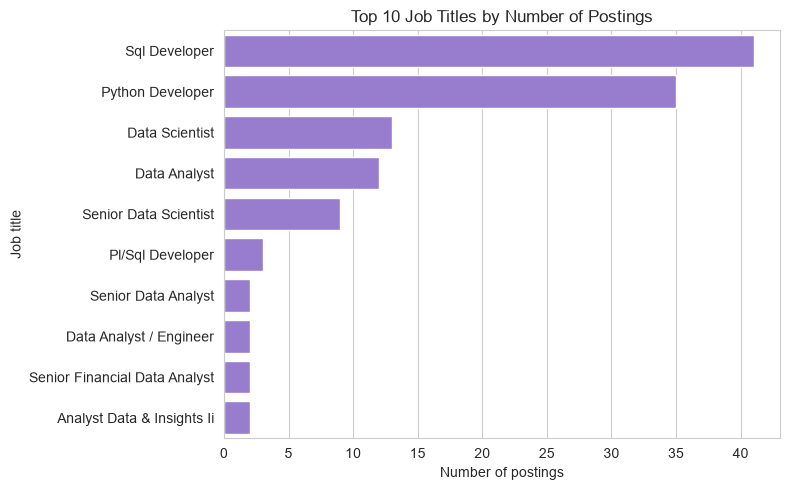

In [7]:
clean_titles = df["title"].str.lower()
top_titles = clean_titles.value_counts().head(10)
top_titles.index = top_titles.index.str.title()

plt.figure(figsize=(8, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, color="mediumpurple")
plt.title("Top 10 Job Titles by Number of Postings")
plt.xlabel("Number of postings")
plt.ylabel("Job title")
plt.tight_layout()
plt.show()

**Insight:** SQL Developer (41) and Python Developer (35) are the most common titles, followed by Data Scientist (13) and Data Analyst (12). Titles were lowercased before counting because the raw data spelled the same role differently (e.g. "SQL Developer" vs "Sql Developer"), which had split one role into two bars. These counts partly reflect the four search terms I chose, so they show what the searches returned, not overall market share.

## 6. In-demand skills (AI-extracted)

Job descriptions are free text, so counting skills with simple keyword matching would miss variations. Instead, each description was sent to an LLM (Gemini) with a prompt asking for up to 5 **specific named tools, languages or platforms**, and explicitly excluding generic phrases like "data analysis" or "communication skills". If nothing concrete was mentioned, the model was told to return an empty list instead of guessing.

Postings with at least one extracted skill: 107 / 200


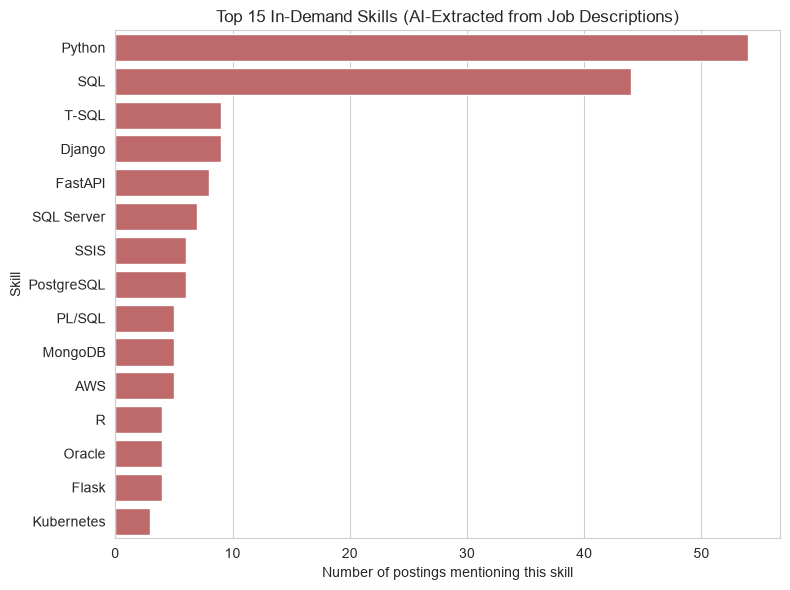

In [8]:
total_jobs = len(df)
with_skills = pd.read_sql("SELECT COUNT(DISTINCT job_id) AS n FROM skills", conn)["n"].iloc[0]
print(f"Postings with at least one extracted skill: {with_skills} / {total_jobs}")

top_skills = pd.read_sql("""
    SELECT skill_name, COUNT(*) AS mentions
    FROM skills
    GROUP BY skill_name
    ORDER BY mentions DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_skills["mentions"], y=top_skills["skill_name"], color="indianred")
plt.title("Top 15 In-Demand Skills (AI-Extracted from Job Descriptions)")
plt.xlabel("Number of postings mentioning this skill")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

**Insight:** Named tools could be extracted from 107 of 200 postings. Python (54) and SQL (44) lead by a wide margin, followed by T-SQL and Django (9 each), FastAPI (8) and SQL Server (7). **Caveat:** two of my four searches were "python developer" and "sql developer", so Python and SQL appearing on top is partly built into the search terms. The more informative part of this chart is the tail: which frameworks and databases go alongside them (Django, FastAPI, SSIS, PostgreSQL, MongoDB, AWS).

In [9]:
sample = pd.read_sql("""
    SELECT j.title, j.description, GROUP_CONCAT(s.skill_name, ', ') AS extracted
    FROM jobs j JOIN skills s ON j.job_id = s.job_id
    GROUP BY j.job_id
    ORDER BY RANDOM()
    LIMIT 5
""", conn)

for _, row in sample.iterrows():
    print(row["title"])
    print("  Text:     ", row["description"][:300])
    print("  Extracted:", row["extracted"], "\n")

SQL Developer
  Text:      Job Description: Candidate need to handle the ticket raised by the team, where they asked to perform the operations on database. Once ticket get’s solved they need to update team for the same. What would be the key responsibilities expected out of this role 1) Help write and optimize in-application 
  Extracted: SQL 

python Developer
  Text:      Hiring: Python Developer | Bangalore | Hybrid Artech is hiring experienced Python Developers for an exciting opportunity in Bangalore. Experience: 3–6 Years Location: Bangalore Work Mode: Hybrid CTC: Up to 10 LPA Preference: Bangalore local candidates Interested candidates can share their updated CV
  Extracted: Angular, Django, Flask, Python, React 

Data Scientist
  Text:      Role  Data Scientist Required Technical Skill Set Good understanding of machine learning including with extensive hands-on experience in model building using libraries like scikit-learn etc. Knowledge of data management and visualization tec

I spot-checked a random sample and the extractions matched the text

## 7. Limitations

- **Small, single-snapshot sample:** 200 postings from one API, one country, one point in time.
- **Search-term bias:** results reflect the four searches I chose, not the whole market.
- **Salary coverage is 20%** (40 of 200), and only two roles had any salary data.
- **Descriptions are truncated to 500 characters** by the API, and many postings use generic wording with no named tools. 93 of 200 had no extractable skill.
- **Skill names are not normalised:** "SQL", "T-SQL" and "SQL Server" are counted separately.
- **Some old creation dates (2019-2021)**, likely reposted listings that kept their original date.
- **Free-tier API limits** constrained how fast the AI step could run, so extraction was done in batches.

## 8. Conclusion

- **Python and SQL dominate** postings that name tools, with Django, FastAPI and SQL Server as the next most common.
- **Karnataka leads hiring** (71 of 200 postings), followed by Maharashtra and Telangana.
- **Hiring is spread across many companies**; no single employer dominates the sample.
- **Over half the postings (107 of 200) name at least one concrete tool**, so the AI step added real signal that titles alone couldn't give.

**What I'd do next:** re-run the pipeline on a schedule to track trends over time, fetch full descriptions from each posting's link instead of the 500-character preview, and normalise skill names (e.g. group T-SQL and SQL Server under SQL).

In [10]:
conn.close()